# 02 · Cognate-vs-unrelated epitope benchmark (Fig 2a/2b)

Reproduces `code_paper/3_Benchmark_cognate_unrelated_epitopes.Rmd` on the **2026 TCRen**.
For each non-redundant αβ structure we thread the cognate epitope plus 1000 random decoy
peptides (same length, anchor positions 2 and last kept, the rest randomised) onto the TCR–
peptide contact map and sum the potential. The **cognate epitope rank** = % of decoys scoring
better (lower energy) than the cognate — lower is better discrimination.

Scoring is done directly from the cached contact table (`pos.to` = peptide position,
`residue.aa.from` = TCR residue), which matches `tcren.scoring.score_peptides` exactly. We
compare TCRen (2026 full + leave-one-out), TCRen 2022, the MJ and Keskin structural potentials,
and a shuffled-TCRen random control. Matrix correlations can shift with pseudocount / Cys
handling, so the **rank** is the performance metric of record.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, polars as pl
from tcren.potential import mj, keskin

rng = np.random.default_rng(0)
R = 'results_new'
AA = list('LFIMVWYCHAGPTSQNDERK'); AIDX = {a: i for i, a in enumerate(AA)}

contacts = pl.read_csv(f'{R}/contacts_2026.csv')
markup = pl.read_csv(f'{R}/markup_2026.csv')
loo = pl.read_csv(f'{R}/TCRen_2026_LOO.csv')
nonred = sorted(loo['pdb.id'].unique().to_list())   # the 2026 non-redundant set
peptide_of = {r['pdb.id']: r['peptide'] for r in markup.iter_rows(named=True) if r['peptide']}
print(f'non-redundant 2026 structures: {len(nonred)}')

non-redundant 2026 structures: 219


In [2]:
# Potentials as 20x20 matrices (rows = TCR residue.aa.from, cols = peptide residue.aa.to).
def mat_from(df, vcol):
    m = np.zeros((20, 20))
    for r in df.iter_rows(named=True):
        i, j = AIDX.get(r['residue.aa.from']), AIDX.get(r['residue.aa.to'])
        if i is not None and j is not None:
            m[i, j] = r[vcol]
    return m

pots = {
    'TCRen 2026': mat_from(pl.read_csv(f'{R}/TCRen_2026.csv'), 'value'),
    'TCRen 2022': mat_from(pl.read_csv(f'{R}/TCRen_2022.csv'), 'value'),
    'MJ': mat_from(mj().matrix, 'value'),
    'Keskin': mat_from(keskin().matrix, 'value'),
}
_r = pots['TCRen 2026'].ravel().copy(); rng.shuffle(_r); pots['random'] = _r.reshape(20, 20)
loo_mat = {pid: mat_from(loo.filter(pl.col('pdb.id') == pid), 'TCRen.LOO') for pid in nonred}
print('potentials:', list(pots) + ['TCRen 2026 (LOO)'])

potentials: ['TCRen 2026', 'TCRen 2022', 'MJ', 'Keskin', 'random', 'TCRen 2026 (LOO)']


In [3]:
# Benchmark: cognate epitope rank among 1000 anchor-preserving random decoys.
N_DECOY = 1000
ab = contacts.filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']))
ranks = {k: [] for k in list(pots) + ['TCRen 2026 (LOO)']}
for pid in nonred:
    cog = peptide_of.get(pid)
    if not cog or len(cog) < 4 or any(a not in AIDX for a in cog):
        continue
    sub = ab.filter(pl.col('pdb.id') == pid)
    pos = np.array(sub['pos.to'].to_list())
    tcr = np.array([AIDX.get(a, -1) for a in sub['residue.aa.from'].to_list()])
    keep = (pos >= 0) & (pos < len(cog)) & (tcr >= 0)
    pos, tcr = pos[keep], tcr[keep]
    if len(pos) == 0:
        continue
    L = len(cog); cogv = np.array([AIDX[a] for a in cog])
    dec = rng.integers(0, 20, size=(N_DECOY, L)); dec[:, 1] = cogv[1]; dec[:, L - 1] = cogv[L - 1]
    allp = np.vstack([cogv[None, :], dec])          # (N+1, L), row 0 = cognate
    contact_aa = allp[:, pos]                         # (N+1, K)
    for name, m in {**pots, 'TCRen 2026 (LOO)': loo_mat.get(pid)}.items():
        if m is None:
            continue
        sc = m[tcr[None, :], contact_aa].sum(axis=1)  # (N+1,)
        ranks[name].append(float((sc[1:] < sc[0]).mean() * 100))
print('structures scored:', len(ranks['TCRen 2026']))

structures scored: 218


In [4]:
# Median cognate-epitope rank + rank-based AUC (= mean(1 - rank/100)); lower rank / higher AUC better.
order = ['TCRen 2026 (LOO)', 'TCRen 2026', 'TCRen 2022', 'Keskin', 'MJ', 'random']
summary = pl.DataFrame([
    {'potential': k, 'n': len(ranks[k]),
     'median_rank_%': round(float(np.median(ranks[k]))),
     'mean_rank_%': round(float(np.mean(ranks[k]))),
     'AUC': round(1 - np.mean(ranks[k]) / 100, 2)}
    for k in order if ranks[k]])
summary.write_csv(f'{R}/benchmark_cognate_ranks.csv')
summary

potential,n,median_rank_%,mean_rank_%,AUC
str,i64,i64,i64,f64
"""TCRen 2026 (LOO)""",218,19,28,0.72
"""TCRen 2026""",218,5,12,0.88
"""TCRen 2022""",218,8,19,0.81
"""Keskin""",218,42,46,0.54
"""MJ""",218,41,44,0.56
"""random""",218,47,49,0.51


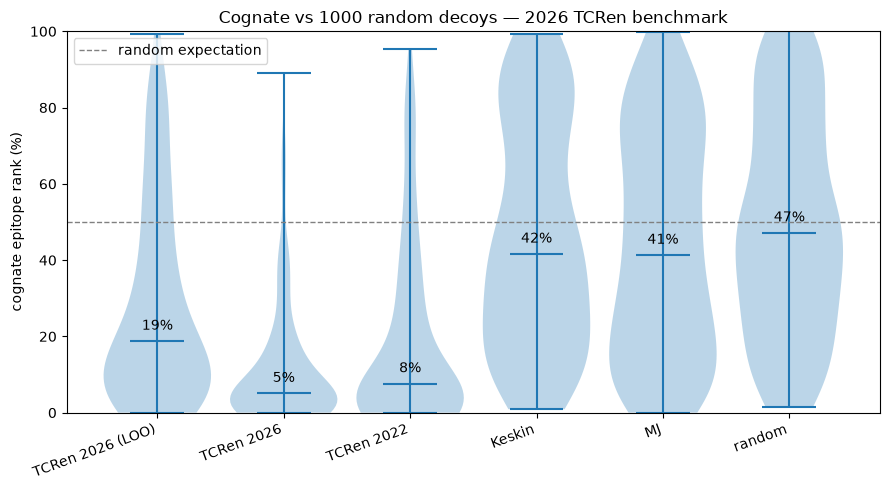

In [5]:
# Fig 2a: cognate-epitope rank distribution per potential (lower = better).
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 5))
data = [ranks[k] for k in order]
parts = ax.violinplot(data, showmedians=True, widths=0.85)
for i, k in enumerate(order, 1):
    ax.text(i, np.median(ranks[k]) + 3, f'{round(np.median(ranks[k]))}%', ha='center', fontsize=10)
ax.set_xticks(range(1, len(order) + 1)); ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('cognate epitope rank (%)'); ax.set_ylim(0, 100)
ax.axhline(50, ls='--', c='grey', lw=1, label='random expectation')
ax.set_title('Cognate vs 1000 random decoys — 2026 TCRen benchmark'); ax.legend()
plt.tight_layout()

## IEDB MHC-matched control (Fig 2b)

The random-decoy benchmark above keeps only the anchor positions fixed. A stricter control
(`code_paper/3_Benchmark_cognate_unrelated_epitopes.Rmd`, "control peptides from IEDB") asks
the cognate epitope to out-score **real eluted-ligand peptides presented by the same MHC**.

For each non-redundant structure we take its MHC allele from the tcren MHC mapper
(`tcren.paper.mhc_annotation` — one batched mmseqs search over `Native2026`, replacing the
legacy `PDB_MHC_annotation` table) and draw up to 1000 IEDB peptides of the **same length**
presented by the **same MHC group** (≥100 required). MHC alleles are normalised to the paper's
grouping: class I → 2-field allele group (e.g. `HLA-A*02`), class II → locus (e.g. `HLA-DR`),
mouse → `H-2`. This is a harder, more realistic decoy set than random sequences.

In [6]:
# Per-structure MHC allele (tcren mapper, replaces legacy PDB_MHC_annotation) + IEDB decoy pools.
from tcren.paper import mhc_annotation

mhc_path = Path(f'{R}/mhc_2026.csv')
if mhc_path.exists():
    mhc = pl.read_csv(mhc_path)
else:
    mhc = mhc_annotation('../data/Native2026', ids=nonred)   # one batched mmseqs search
    mhc.write_csv(mhc_path)

def mhc_norm(s):
    """Paper MHC grouping: class I -> 2-field group, class II -> locus, mouse -> H-2."""
    if not s:
        return None
    m = s.split(':')[0]
    if m.startswith('H2-') or m.startswith('H-2'):
        return 'H-2'
    if m.startswith('HLA-D'):
        return m[:6]
    return m

mhc_of = {r['pdb.id']: mhc_norm(r['mhc.allele']) for r in mhc.iter_rows(named=True)}

# IEDB eluted-ligand peptides -> {(MHC group, length): [peptides]} decoy pools (vectorised).
AA_RE = r'^[LFIMVWYCHAGPTSQNDERK]+$'
iedb = (pl.read_csv('data_legacy/iedb_slim.csv.gz')
        .filter((pl.col('Assay.1') == 'cellular MHC/mass spectrometry') &
                (pl.col('Assay.5') == 'Positive') & (pl.col('Epitope.1') == 'Linear peptide'))
        .with_columns(grp=pl.col('MHC').str.split(':').list.first())
        .with_columns(
            mhcnorm=pl.when(pl.col('grp').str.starts_with('H2-') | pl.col('grp').str.starts_with('H-2'))
                      .then(pl.lit('H-2'))
                      .when(pl.col('grp').str.starts_with('HLA-D')).then(pl.col('grp').str.slice(0, 6))
                      .otherwise(pl.col('grp')),
            pep=pl.col('Epitope.2'))
        .filter(pl.col('pep').str.contains(AA_RE))
        .with_columns(L=pl.col('pep').str.len_chars()))
pools = {(r['mhcnorm'], r['L']): r['peps']
         for r in iedb.group_by(['mhcnorm', 'L']).agg(pl.col('pep').unique().alias('peps')).iter_rows(named=True)}
print(f'MHC annotated: {mhc.height} structures '
      f'({mhc.filter(pl.col("mhc.class") == "MHCI").height} MHCI / '
      f'{mhc.filter(pl.col("mhc.class") == "MHCII").height} MHCII)')
print(f'IEDB eluted-ligand peptides: {iedb.height:,}; MHC-group x length pools: {len(pools):,}')

MHC annotated: 219 structures (151 MHCI / 68 MHCII)
IEDB eluted-ligand peptides: 900,569; MHC-group x length pools: 970


In [7]:
# Cognate-epitope rank among up to 1000 real IEDB decoys of the same MHC group + length.
rng2 = np.random.default_rng(1)
ranks_iedb = {k: [] for k in order}
for pid in nonred:
    cog = peptide_of.get(pid); mn = mhc_of.get(pid)
    if not cog or mn is None or len(cog) < 4 or any(a not in AIDX for a in cog):
        continue
    decoys = [p for p in pools.get((mn, len(cog)), []) if p != cog]
    if len(decoys) <= 100:                      # paper threshold: need a real decoy pool
        continue
    if len(decoys) > 1000:
        decoys = [decoys[i] for i in rng2.choice(len(decoys), 1000, replace=False)]
    sub = ab.filter(pl.col('pdb.id') == pid)
    pos = np.array(sub['pos.to'].to_list())
    tcr = np.array([AIDX.get(a, -1) for a in sub['residue.aa.from'].to_list()])
    keep = (pos >= 0) & (pos < len(cog)) & (tcr >= 0)
    pos, tcr = pos[keep], tcr[keep]
    if len(pos) == 0:
        continue
    allp = np.array([[AIDX[a] for a in cog]] + [[AIDX[a] for a in d] for d in decoys])  # (N+1, L)
    contact_aa = allp[:, pos]                    # (N+1, K)
    for name in order:
        m = loo_mat.get(pid) if name == 'TCRen 2026 (LOO)' else pots.get(name)
        if m is None:
            continue
        sc = m[tcr[None, :], contact_aa].sum(axis=1)
        ranks_iedb[name].append(float((sc[1:] < sc[0]).mean() * 100))

summary_iedb = pl.DataFrame([
    {'potential': k, 'n': len(ranks_iedb[k]),
     'median_rank_%': round(float(np.median(ranks_iedb[k]))),
     'mean_rank_%': round(float(np.mean(ranks_iedb[k]))),
     'AUC': round(1 - np.mean(ranks_iedb[k]) / 100, 2)}
    for k in order if ranks_iedb[k]])
summary_iedb.write_csv(f'{R}/benchmark_cognate_iedb_ranks.csv')
summary_iedb

potential,n,median_rank_%,mean_rank_%,AUC
str,i64,i64,i64,f64
"""TCRen 2026 (LOO)""",204,20,31,0.69
"""TCRen 2026""",204,5,13,0.87
"""TCRen 2022""",204,8,20,0.8
"""Keskin""",204,32,39,0.61
"""MJ""",204,26,34,0.66
"""random""",204,42,45,0.55


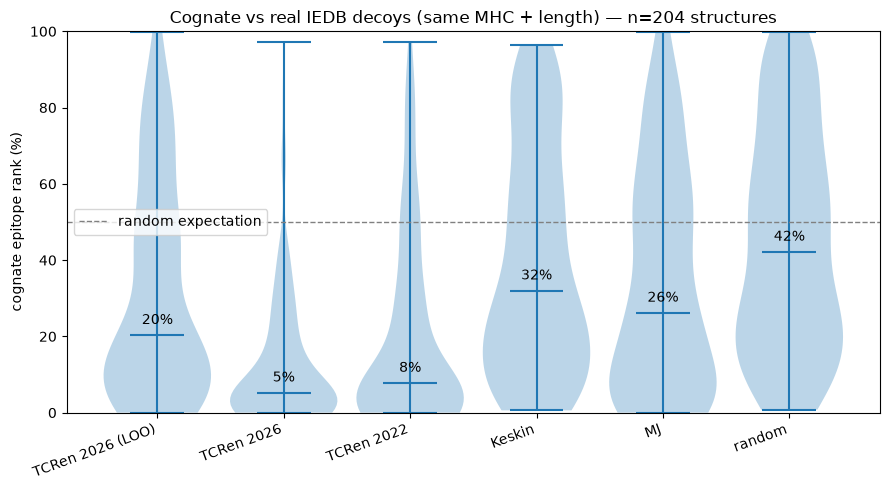

In [8]:
# Fig 2b: cognate-epitope rank vs real IEDB decoys (same MHC group + length; lower = better).
fig, ax = plt.subplots(figsize=(9, 5))
data = [ranks_iedb[k] for k in order]
ax.violinplot(data, showmedians=True, widths=0.85)
for i, k in enumerate(order, 1):
    ax.text(i, np.median(ranks_iedb[k]) + 3, f'{round(np.median(ranks_iedb[k]))}%', ha='center', fontsize=10)
ax.set_xticks(range(1, len(order) + 1)); ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('cognate epitope rank (%)'); ax.set_ylim(0, 100)
ax.axhline(50, ls='--', c='grey', lw=1, label='random expectation')
ax.set_title(f'Cognate vs real IEDB decoys (same MHC + length) — n={len(ranks_iedb[order[0]])} structures')
ax.legend(); plt.tight_layout()